In [1]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance
import os
from itertools import combinations




In [2]:
#LOAD GMM CLUSTER CSV
df = pd.read_csv("clustered_data_gmm.csv")


print("Colonne disponibili:\n", df.columns.tolist())

Colonne disponibili:
 ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19', 'PC20', 'dport_0', 'dport_22', 'dport_53', 'dport_80', 'dport_443', 'dport_465', 'src_port_medium', 'src_port_high', 'protocol_6', 'protocol_17', 'inbound', 'label', 'cluster_assignment']


In [3]:
#LOAD CODE MAP CSV
map_df = pd.read_csv("label_code_map.csv")


In [4]:
#Names of label column and cluster_id column
#"label"
#"cluster_assignment"


In [5]:
#Convert label_col and cluster_col to int

#print(df.shape)      

df["cluster_assignment"] = pd.to_numeric(df["cluster_assignment"], errors="coerce")
df["label"] = pd.to_numeric(df["label"], errors="coerce")

df = df.dropna(subset=["cluster_assignment", "label"]).copy()   #is clean you can remove

df["cluster_assignment"] = df["cluster_assignment"].astype(int)
df["label"] = df["label"].astype(int)

#print(df.shape)      


In [6]:
#Automatic number to name conversion
code_to_name = dict(zip(map_df["label_code"], map_df["label_name"]))


In [7]:
#BUILD ALL CONTINGENCY TABLES

#Count contingency table
ct_counts = pd.crosstab(df["label"].map(code_to_name), df["cluster_assignment"])

#Row-%-normalized contingency table
ct_row_pct = pd.crosstab(df["label"].map(code_to_name), df["cluster_assignment"], normalize="index") * 100

#Column-%-normalized contingency table
ct_col_pct = pd.crosstab(df["label"].map(code_to_name), df["cluster_assignment"], normalize="columns") * 100


In [8]:
print(df["label"].value_counts().head(30))

label
11    5986
6     5984
7     5970
2     5928
3     5911
10    5876
4     5830
0     5657
8     5480
1     5369
9     5261
5      986
Name: count, dtype: int64


In [9]:
#Print of tables
print("\n=== Count ===")
print(ct_counts)

print("\n=== Contingency row-normalized ===")
print(ct_row_pct.round(2))

print("\n=== Contingency column-normalized ===")
print(ct_col_pct.round(2))


=== Count ===
cluster_assignment    0    1     2     3     4    5    6     7    8   9   10  \
label                                                                          
benign                17  702     0     0   903  172  758     0  938   0  28   
ddos_dns             495   18     0  4062     7   31    0   645   39   0   6   
ddos_ldap             20    0     0     0     0    1    0  5905    1   0   1   
ddos_mssql            42    4     0     0     0    0    0  5864    0   1   0   
ddos_netbios        5557    0     0     0     0    1    0   272    0   0   0   
ddos_ntp               4  190     0     0    44   31    0     0  122   0   1   
ddos_snmp           5984    0     0     0     0    0    0     0    0   0   0   
ddos_ssdp             26    1     0     0     0    1    0  5939    1   0   2   
ddos_syn               0  241  2775     0  2370   11    0     0    0   0   0   
ddos_tftp              3    1  3729     0  1463   10    0     0    0   0   0   
ddos_udp            5873 

In [10]:
#Save the csv of tables
ct_counts.to_csv("contingency_counts.csv")
ct_row_pct.round(4).to_csv("contingency_row_normalized_pct.csv")
ct_col_pct.round(4).to_csv("contingency_col_normalized_pct.csv")



In [11]:
n_clusters = df["cluster_assignment"].nunique(dropna=True)
print("Number of differents clusters:", n_clusters)

Number of differents clusters: 13


In [12]:
#GENERATE AND SAVE HEATMAPS

HEATMAP_ROW_PNG = "heatmap_row_normalized_pct.png"
HEATMAP_COL_PNG = "heatmap_col_normalized_pct.png"


def generate_and_save_heatmap(df_vals, title, out_png, fmt="{:.1f}", dpi=300):
    
    values = df_vals.values
    n_rows, n_cols = values.shape

    # figure size
    fig_w = max(8, 0.6 * n_cols)
    fig_h = max(4, 0.4 * n_rows)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(values, aspect="auto")

    ax.set_title(title)
    ax.set_xlabel("cluster_id")
    ax.set_ylabel("Label")

    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(df_vals.columns.tolist(), rotation=45, ha="right")
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(df_vals.index.tolist())

    # color_bar
    fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02)

    
    for i in range(n_rows):
        for j in range(n_cols):
            ax.text(j, i, fmt.format(values[i, j]), ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.savefig(out_png, dpi=dpi, bbox_inches="tight")
    plt.close(fig)




generate_and_save_heatmap(ct_row_pct, "Row-normalized contingency table (%)\n(Distribution of each Label across clusters)",
             HEATMAP_ROW_PNG, fmt="{:.1f}")
generate_and_save_heatmap(ct_col_pct, "Column-normalized contingency table (%)\n(Composition of each cluster by Label)",
             HEATMAP_COL_PNG, fmt="{:.1f}")

print("Salvate heatmap:")
print(" -", HEATMAP_ROW_PNG)
print(" -", HEATMAP_COL_PNG)



Salvate heatmap:
 - heatmap_row_normalized_pct.png
 - heatmap_col_normalized_pct.png


In [13]:
#df['label'].value_counts().head(20) 

Cluster per class:
 label
benign          9
ddos_dns        9
ddos_ldap       5
ddos_mssql      4
ddos_netbios    3
ddos_ntp        7
ddos_snmp       1
ddos_ssdp       6
ddos_syn        5
ddos_tftp       6
ddos_udp        3
ddos_udp_lag    1
dtype: int64


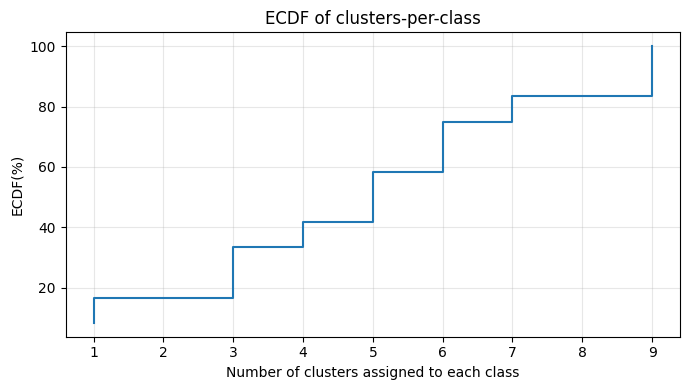

In [14]:
#GENERATE ECDF

# ct_counts: contingency table (counts), righe=label, colonne=cluster


# 1) Numer of class for each class 
clusters_per_class = (ct_counts > 0).sum(axis=1)  #use contingency table

print("Cluster per class:\n", clusters_per_class)

# 2) ECDF
x = np.sort(clusters_per_class.values)
y = np.arange(1, len(x) + 1) / len(x)* 100

# 3) Plot ECDF
plt.figure(figsize=(7,4))
plt.step(x, y, where="post")
plt.xlabel("Number of clusters assigned to each class")
plt.ylabel("ECDF(%)")
plt.title("ECDF of clusters-per-class")
plt.xticks(range(int(x.min()), int(x.max()) + 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("ecdf_clusters_per_class.png", dpi=300)
plt.show()

In [15]:
#I REMOVE CLUSTER 9 FROM DF IT HAVE ONLY ONE ELEMENT
print(df.shape)
df = df[df["cluster_assignment"] != 9].reset_index(drop=True)
print(df.shape)

(64238, 33)
(64237, 33)


In [16]:
#Copy for exegute part 4.2 and part 4.3
df_copy = df.copy(deep=True)

In [17]:
#I DECIDED TO DO HERE PART 4.3 BEFORE PART 4.2
#I selected 3 classes: ddos_syn,ddos_dftp,ddos_ntp
#I calculate for each one statistics and distribution on each cluster 

#ddos_syn:  It's present on cluster 2 and 4


TOPK = 10
OUT_DIR = "43a_step_syn"
os.makedirs(OUT_DIR, exist_ok=True)

lab = 8 #"ddos_syn"
df_lab = df[df["label"] == lab].copy()  #Select only the row of this class

print("Number of attacks ddos_syn:", len(df_lab))
print("Discrition cluster for ddos_syn:")
print(df_lab["cluster_assignment"].value_counts().sort_index())






Number of attacks ddos_syn: 5480
Discrition cluster for ddos_syn:
cluster_assignment
1      241
2     2775
4     2370
5       11
11      83
Name: count, dtype: int64


I compared only cluster 2 and 4: 2 vs 4
Number of attack on two clusters chosen:
cluster_assignment
2    2775
4    2370
Name: count, dtype: int64
Numer of total feature: 31

TOP feature with hightest median difference:
                 median_cluster2  median_cluster4  abs_median_diff
PC7                     0.965407        -2.727803         3.693211
PC3                     0.810196         4.466611         3.656416
PC1                    -1.813609        -5.419304         3.605695
PC6                     2.638078        -0.922177         3.560255
PC2                    -3.217495        -0.940495         2.277000
PC10                   -0.540725         1.079491         1.620216
PC8                     0.528011        -0.899233         1.427245
PC14                    0.420020        -0.954448         1.374468
PC13                    0.291266        -0.847661         1.138927
src_port_medium         0.000000         1.000000         1.000000


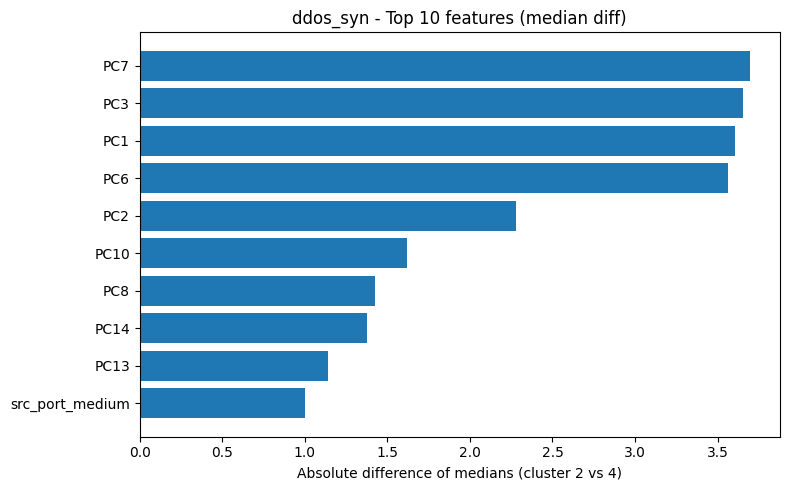

Top2 feature per boxplot: ['PC7', 'PC3']


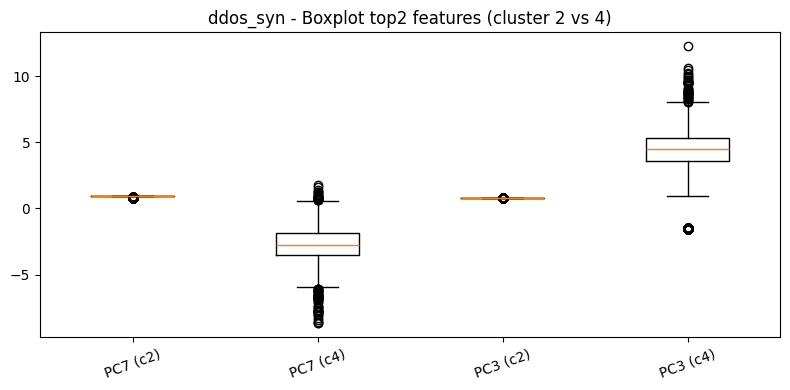

In [18]:
#ANALISIS OF ddos_syn

top2 = df_lab["cluster_assignment"].value_counts().head(2).index.tolist()
cA, cB = top2[0], top2[1]
print("I compared only cluster 2 and 4:", cA, "vs", cB)

df_syn = df_lab[df_lab["cluster_assignment"].isin([cA, cB])].copy()
print("Number of attack on two clusters chosen:")
print(df_syn["cluster_assignment"].value_counts().sort_index())


X_num = df_syn.drop(columns=["label", "cluster_assignment"], errors="ignore").select_dtypes(include=[np.number])

print("Numer of total feature:", X_num.shape[1])

# I compute the medians for each cluster
med = df_syn.groupby("cluster_assignment")[X_num.columns].median()

# Absolute difference between the cluster medians
diff = (med.loc[cA] - med.loc[cB]).abs().sort_values(ascending=False)

top_features = diff.head(TOPK).index.tolist()

# final table (medians + difference)
tab = pd.DataFrame({
    f"median_cluster{cA}": med.loc[cA, top_features],
    f"median_cluster{cB}": med.loc[cB, top_features],
    "abs_median_diff": diff.loc[top_features]
}).sort_values("abs_median_diff", ascending=False)

print("\nTOP feature with hightest median difference:")
print(tab)

# save table
tab.to_csv(os.path.join(OUT_DIR, f"ddos_syn_median_table_top{TOPK}_c{cA}_vs_c{cB}.csv"), index=True)

# barplot differenze
plt.figure(figsize=(8,5))
plt.barh(tab.index[::-1], tab["abs_median_diff"].values[::-1])
plt.xlabel(f"Absolute difference of medians (cluster {cA} vs {cB})")
plt.title(f"{"ddos_syn"} - Top {TOPK} features (median diff)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f"{lab}_bar_median_diff_c{cA}_vs_c{cB}.png"), dpi=300)
plt.show()

# boxplot top2 feature
top2_feats = tab.index[:2].tolist()
print("Top2 feature per boxplot:", top2_feats)

plt.figure(figsize=(8,4))
data_plot = [
    df_syn[df_syn["cluster_assignment"]==cA][top2_feats[0]].values,
    df_syn[df_syn["cluster_assignment"]==cB][top2_feats[0]].values,
    df_syn[df_syn["cluster_assignment"]==cA][top2_feats[1]].values,
    df_syn[df_syn["cluster_assignment"]==cB][top2_feats[1]].values
]
plt.boxplot(data_plot, tick_labels=[
    f"{top2_feats[0]} (c{cA})", f"{top2_feats[0]} (c{cB})",
    f"{top2_feats[1]} (c{cA})", f"{top2_feats[1]} (c{cB})"
])
plt.title(f"{"ddos_syn"} - Boxplot top2 features (cluster {cA} vs {cB})")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f"{lab}_boxplot_top2_c{cA}_vs_c{cB}.png"), dpi=300)
plt.show()


In [19]:
#ANALISIS OF ddos_tftp

lab = 9 #ddos_tftp
df_lab = df[df["label"] == lab].copy()

print("Number of flow for ddos_tftp:", len(df_lab))
print("Distribution cluster for ddos_tftp:")
print(df_lab["cluster_assignment"].value_counts().sort_index())


Number of flow for ddos_tftp: 5261
Distribution cluster for ddos_tftp:
cluster_assignment
0        3
1        1
2     3729
4     1463
5       10
11      55
Name: count, dtype: int64


I compare the main clusters 2 e 4: 2 vs 4
Count in cluster choise:
cluster_assignment
2    3729
4    1463
Name: count, dtype: int64

TOP feature selected from median difference (TFTP):
      median_cluster2  median_cluster4  abs_median_diff
PC1         -1.813609        -3.867926         2.054317
PC19        -0.045686         1.793780         1.839466
PC18         0.245494        -1.364459         1.609953
PC6          2.638078         1.096507         1.541571
PC2         -3.217495        -1.696692         1.520803
PC7          0.965407        -0.490336         1.455743
PC3          0.810196         1.803833         0.993638
PC4         -0.823900        -0.116683         0.707216
PC14         0.420020        -0.198122         0.618143
PC10        -0.540725        -0.102704         0.438020


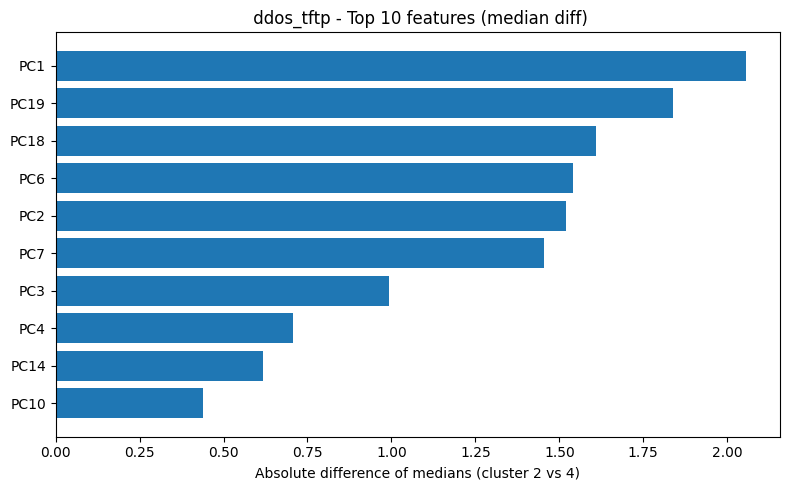

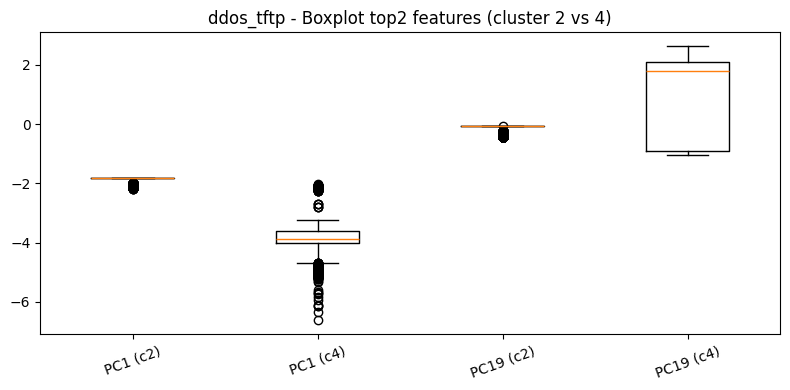

In [20]:
#ANALISIS OF ddos_tftp

TOPK = 10
OUT_DIR = "43a_step_tftp"
os.makedirs(OUT_DIR, exist_ok=True)

# I select the two clusters with the highest frequency within the label
top2 = df_lab["cluster_assignment"].value_counts().head(2).index.tolist()
cA, cB = top2[0], top2[1]
print("I compare the main clusters 2 e 4:", cA, "vs", cB)

df_tftp = df_lab[df_lab["cluster_assignment"].isin([cA, cB])].copy()
print("Count in cluster choise:")
print(df_tftp["cluster_assignment"].value_counts().sort_index())

# numeric feature numeriche (without label e cluster)
X_num = df_tftp.drop(columns=["label", "cluster_assignment"], errors="ignore") \
              .select_dtypes(include=[np.number])

# medians for each cluster
med = df_tftp.groupby("cluster_assignment")[X_num.columns].median()

# abs medians difference
diff = (med.loc[cA] - med.loc[cB]).abs().sort_values(ascending=False)
top_features = diff.head(TOPK).index.tolist()

tab = pd.DataFrame({
    f"median_cluster{cA}": med.loc[cA, top_features],
    f"median_cluster{cB}": med.loc[cB, top_features],
    "abs_median_diff": diff.loc[top_features]
}).sort_values("abs_median_diff", ascending=False)

print("\nTOP feature selected from median difference (TFTP):")
print(tab)

# save table
tab.to_csv(os.path.join(OUT_DIR, f"{"ddos_tftp"}_median_table_top{TOPK}_c{cA}_vs_c{cB}.csv"), index=True)

# plot 1: barplot differenze
plt.figure(figsize=(8,5))
plt.barh(tab.index[::-1], tab["abs_median_diff"].values[::-1])
plt.xlabel(f"Absolute difference of medians (cluster {cA} vs {cB})")
plt.title(f"{" ddos_tftp"} - Top {TOPK} features (median diff)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f"{lab}_bar_median_diff_c{cA}_vs_c{cB}.png"), dpi=300)
plt.show()

# plot 2: boxplot top2 feature
top2_feats = tab.index[:2].tolist()
plt.figure(figsize=(8,4))
data_plot = [
    df_tftp[df_tftp["cluster_assignment"]==cA][top2_feats[0]].values,
    df_tftp[df_tftp["cluster_assignment"]==cB][top2_feats[0]].values,
    df_tftp[df_tftp["cluster_assignment"]==cA][top2_feats[1]].values,
    df_tftp[df_tftp["cluster_assignment"]==cB][top2_feats[1]].values
]
plt.boxplot(data_plot, tick_labels=[
    f"{top2_feats[0]} (c{cA})", f"{top2_feats[0]} (c{cB})",
    f"{top2_feats[1]} (c{cA})", f"{top2_feats[1]} (c{cB})"
])
plt.title(f"{"ddos_tftp"} - Boxplot top2 features (cluster {cA} vs {cB})")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f"{lab}_boxplot_top2_c{cA}_vs_c{cB}.png"), dpi=300)
plt.show()


N campioni per 5 : 986
Distribution of clusters per NTP:
cluster_assignment
0       4
1     190
4      44
5      31
8     122
10      1
11    594
Name: count, dtype: int64


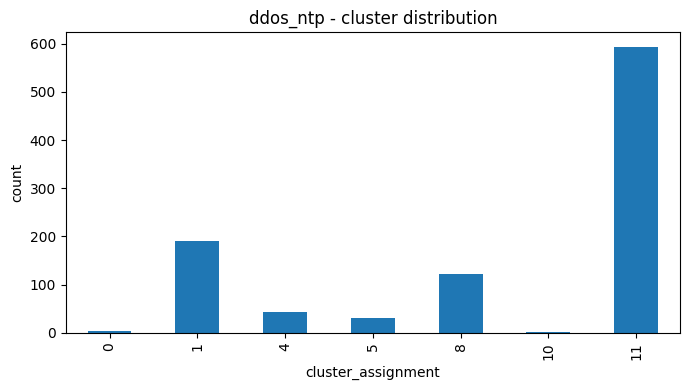

In [21]:
#ANALISIS OF ddos_ntp

lab = 5 #ddos_ntp
df_ntp = df[df["label"] == lab].copy()

print("N campioni per", lab, ":", len(df_ntp))
counts = df_ntp["cluster_assignment"].value_counts().sort_index()
print("Distribution of clusters per NTP:")
print(counts)

# barplot distribution cluster

OUT_DIR = "43a_step_ntp"
os.makedirs(OUT_DIR, exist_ok=True)

plt.figure(figsize=(7,4))
counts.plot(kind="bar")
plt.title("ddos_ntp - cluster distribution")
plt.xlabel("cluster_assignment")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "ddos_ntp_cluster_distribution.png"), dpi=300)
plt.show()


In [22]:
# ANALYSIS OF ddos_ntp (label = 5) - top3 clusters


# I take 3 hightest flow cluster  
top3 = df_ntp["cluster_assignment"].value_counts().head(3).index.tolist()
print("Top-3 cluster per NTP:", top3)

df_ntp_top = df_ntp[df_ntp["cluster_assignment"].isin(top3)].copy()

# numeric feature
X_num = df_ntp_top.drop(columns=["label", "cluster_assignment"], errors="ignore") \
                  .select_dtypes(include=[np.number])

# medians for ech cluster
med = df_ntp_top.groupby("cluster_assignment")[X_num.columns].median()

# mesure how many change a feature on  cluster
range_med = (med.max(axis=0) - med.min(axis=0)).sort_values(ascending=False)

top2_feats = range_med.head(2).index.tolist()
print("Top 2 features with the largest variation across NTP clusters:", top2_feats)
print("\nTop10 on medians range:")
print(range_med.head(10))

# table medians top10 high variable feature 
top10 = range_med.head(TOPK).index.tolist()
tab = med[top10].T
tab["median_range_across_clusters"] = range_med.loc[top10].values

print("\ntable medians top10 high variable feature:")
print(tab)

tab.to_csv(os.path.join(OUT_DIR, "ddos_ntp_median_table_top10.csv"), index=True)


Top-3 cluster per NTP: [11, 1, 8]
Top 2 features with the largest variation across NTP clusters: ['PC2', 'PC7']

Top10 on medians range:
PC2     6.471564
PC7     5.851069
PC6     3.338274
PC5     2.904234
PC10    2.847817
PC4     2.785731
PC3     2.660498
PC13    2.203657
PC12    1.567491
PC20    1.115763
dtype: float64

table medians top10 high variable feature:
cluster_assignment         1         8        11  median_range_across_clusters
PC2                 4.000459  2.898526 -2.471105                      6.471564
PC7                 3.964556  3.812376 -1.886513                      5.851069
PC6                 1.245271 -0.043740 -2.093004                      3.338274
PC5                -1.640444 -0.604129  1.263790                      2.904234
PC10                1.182227  0.603708 -1.665590                      2.847817
PC4                -0.474373  1.183050  2.311357                      2.785731
PC3                -2.251127 -2.728665 -4.911625                      2.660498
PC

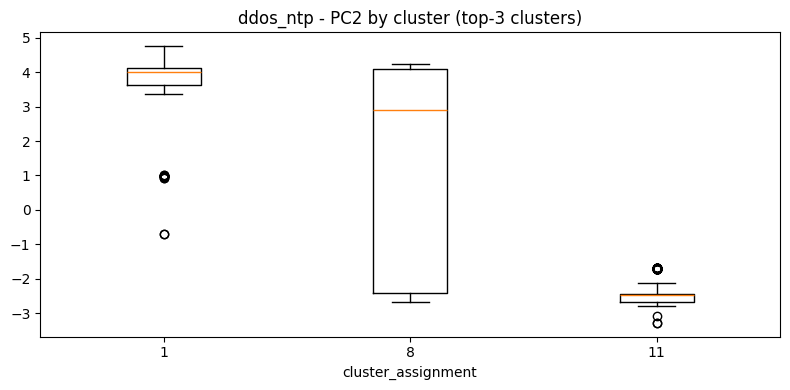

In [23]:

feat = top2_feats[0]  # The hightest variable feature

clusters_sorted = sorted(top3)

plt.figure(figsize=(8,4))
data_plot = [df_ntp_top[df_ntp_top["cluster_assignment"]==c][feat].values for c in clusters_sorted]
plt.boxplot(data_plot, tick_labels=[str(c) for c in clusters_sorted])
plt.title(f"ddos_ntp - {feat} by cluster (top-3 clusters)")
plt.xlabel("cluster_assignment")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f"ddos_ntp_boxplot_{feat}.png"), dpi=300)
plt.show()


In [24]:
#PART 4.3 b)

LABEL_MAP = {
    0:"benign",
    1:"ddos_dns",
    2:"ddos_ldap",
    3:"ddos_mssql",
    4:"ddos_netbios",
    5:"ddos_ntp",
    6:"ddos_snmp",
    7:"ddos_ssdp",
    8:"ddos_syn",
    9:"ddos_tftp",
    10:"ddos_udp",
    11:"ddos_udp_lag",
}

df["label_name"] = df["label"].map(LABEL_MAP)

LABEL_COL = "label_name"

CL_COL = "cluster_assignment"

#In this way I don't tuch df
meta_cols = {CL_COL, "label", "label_name"}
feature_cols = [c for c in df.columns if c not in meta_cols]

def family_pairwise_feature_similarity(df, family_labels, cluster_id, top_k=15, min_nonzero_rate=0.01):
    # FILTER: only flows of the selected family inside the chosen cluster
    sub = df[(df[CL_COL] == cluster_id) & (df[LABEL_COL].isin(family_labels))]

    if sub.empty:
        raise ValueError(
            f"No samples found for family={family_labels} in cluster={cluster_id}. "
            f"Check LABEL_COL='{LABEL_COL}' and label values."
        )

    
    # nonzero rate computed on sub (family + cluster)
    X = sub[feature_cols]
    nonzero_rate = (X != 0).mean(axis=0)

    # keep features that are active enough OR are PCA components
    kept_features = [
        c for c in feature_cols
        if (nonzero_rate.get(c, 0) >= min_nonzero_rate) or str(c).startswith("PC")
    ]

    if len(kept_features) == 0:
        raise ValueError("After filtering sparse features, no features remain. Lower min_nonzero_rate.")

    # Calculate medians for each attack inside the cluster on kept features
    med = sub.groupby(LABEL_COL)[kept_features].median()

    # number of flows per class in this cluster
    counts = sub[LABEL_COL].value_counts().reindex(med.index)
    med_with_n = med.copy()
    med_with_n["n_samples"] = counts.values

    # Pairwise differences (2 by 2)
    labels = list(med.index)
    if len(labels) < 2:
        raise ValueError("Need at least 2 attacks in the family to compute pairwise differences.")

    pair_diffs = []
    pair_names = []

    for a, b in combinations(labels, 2):
        diff = (med.loc[a] - med.loc[b]).abs()
        pair_diffs.append(diff)
        pair_names.append(f"{a} vs {b}")

    pair_diffs_df = pd.DataFrame(pair_diffs, index=pair_names)

    # Score: minimize the maximum pairwise difference (shared similarity across all pairs)
    max_pairwise = pair_diffs_df.max(axis=0).rename("max_pairwise_diff")
    mean_pairwise = pair_diffs_df.mean(axis=0).rename("mean_pairwise_diff")

    score = pd.concat([max_pairwise, mean_pairwise], axis=1).sort_values("max_pairwise_diff", ascending=True)

    top_features = score.head(top_k).index.tolist()

    top_score = score.loc[top_features]
    top_medians = med_with_n[top_features + ["n_samples"]]
    top_pairdiffs = pair_diffs_df[top_features]

    return top_score, top_medians, top_pairdiffs

#families
family_A = ["ddos_ldap", "ddos_mssql", "ddos_ssdp"]
cluster_A = 7

family_B = ["ddos_netbios", "ddos_snmp", "ddos_udp", "ddos_udp_lag"]  
cluster_B = 0


A_score, A_medians, A_pairdiffs = family_pairwise_feature_similarity(df, family_A, cluster_A, top_k=15)
B_score, B_medians, B_pairdiffs = family_pairwise_feature_similarity(df, family_B, cluster_B, top_k=15)



print("\n=== FAMILY A (cluster 7): Top features for similarity (minimize max pairwise diff) ===")
print(A_score)

print("\nPer-attack medians (within the cluster) on top features + n_samples:")
print(A_medians)

print("\nPairwise absolute differences on the top features:")
print(A_pairdiffs)

# --- FAMILY B outputs (cluster 0) ---
print("\n=== FAMILY B (cluster 0): Top features for similarity (minimize max pairwise diff) ===")
print(B_score)

print("\nPer-attack medians (within the cluster) on top features + n_samples:")
print(B_medians)

print("\nPairwise absolute differences on the top features:")
print(B_pairdiffs)


# save results
A_score.to_csv("familyA_top_features_pairwise.csv")
A_medians.to_csv("familyA_medians_in_cluster.csv")
B_score.to_csv("familyB_top_features_pairwise.csv")
B_medians.to_csv("familyB_medians_in_cluster.csv")




=== FAMILY A (cluster 7): Top features for similarity (minimize max pairwise diff) ===
             max_pairwise_diff  mean_pairwise_diff
protocol_17           0.000000            0.000000
inbound               0.000000            0.000000
PC8                   0.020676            0.013784
PC13                  0.021421            0.014281
PC7                   0.029252            0.019501
PC3                   0.065729            0.043819
PC11                  0.093522            0.062348
PC5                   0.103896            0.069264
PC2                   0.142755            0.095170
PC10                  0.159220            0.106146
PC9                   0.169969            0.113312
PC17                  0.182599            0.121733
PC12                  0.282960            0.188640
PC19                  0.313483            0.208988
PC6                   0.314521            0.209681

Per-attack medians (within the cluster) on top features + n_samples:
            protocol_17  i

In [25]:
#MODIFY DF FOR PART 4.2



#Remove label column and label_name
print(df_copy.shape)
df_copy = df_copy.drop(columns=["label"])
print(df_copy.shape)


(64237, 33)
(64237, 32)


In [26]:
#STRATIFY SPLIT

y = df_copy["cluster_assignment"].astype(int)   # target

print(y.value_counts().sort_values())
X = df_copy.drop(columns=["cluster_assignment"])  
print(df_copy.shape)


X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20,random_state=42,stratify=y)


cluster_assignment
10       38
5       259
6       758
11      846
8      1101
1      1157
12     2091
3      4062
4      4787
2      6504
7     18627
0     24007
Name: count, dtype: int64
(64237, 32)


In [27]:
#TRAIN RANDOM FOREST
clf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))

Test accuracy: 0.9985990037359901


In [ ]:
#PERMUTATION IMPORTANCE
perm = permutation_importance(
    clf, X_test, y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
    scoring="f1_macro"
)

imp_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print(imp_df.head(15))
imp_df.to_csv("feature_importance_permutation.csv", index=False)

In [ ]:
#SHOW IMPORTANT FEATURE 
topk = 15
plot_df = imp_df.head(topk).iloc[::-1]

plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.xlabel("Permutation importance (mean decrease in F1-macro)")
plt.title(f"Top {topk} features explaining clusters")
plt.tight_layout()
plt.savefig("feature_importance_top15.png", dpi=300)
plt.show()
